# Exploratory Data Analysis — Guard Patrol Anomaly Detection

## Objective

Analyze the cleaned and OSM-enriched GPS trajectory data
to understand normal guard movement behavior and identify
potential data-quality and anomaly patterns.

## Dataset

GeoLife Trajectory Dataset

## Project Context

The analysis is performed as a foundation for the
VigiloX Guard Patrol Anomaly Detection system.

## Main Investigation Areas

1. Data quality
2. GPS completeness
3. Timestamp consistency
4. Movement behavior
5. Speed behavior
6. GPS jumps
7. Road deviation
8. Guard-wise behavior
9. Temporal behavior
10. Feature relationships

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd().parent
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
print("Project:", PROJECT_DIR)
print("Interim:", INTERIM_DATA_DIR)

Project: e:\Internship\Guard_Patrol_Anomaly_Detection
Interim: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim


# Data Path

In [3]:
DATA_PATH = (
    INTERIM_DATA_DIR /
    "geolife_gps_osm_features.parquet"
)
df = pd.read_parquet(DATA_PATH)
print("Shape:", df.shape)
print(df.head())

Shape: (916, 14)
  guard_id           timestamp   latitude   longitude  altitude_ft  \
0      000 2008-10-23 02:53:04  39.984702  116.318417          492   
1      000 2008-10-23 02:53:10  39.984683  116.318450          492   
2      000 2008-10-23 02:53:15  39.984686  116.318417          492   
3      000 2008-10-23 02:53:20  39.984688  116.318385          492   
4      000 2008-10-23 02:53:25  39.984655  116.318263          492   

   time_gap_seconds  distance_from_previous_m  speed_kmh  gps_jump  \
0               NaN                  0.000000        NaN     False   
1               6.0                  3.520694   2.112417     False   
2               5.0                  2.838241   2.043534     False   
3               5.0                  2.742220   1.974399     False   
4               5.0                 11.045822   7.952992     False   

   distance_to_road_m road_match_status   highway maxspeed  length  
0            5.513269              GOOD  tertiary     None   401.0  
1  

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Rows: 916
Columns: 14

Columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   guard_id                  916 non-null    object        
 1   timestamp                 916 non-null    datetime64[ns]
 2   latitude                  916 non-null    float64       
 3   longitude                 916 non-null    float64       
 4   altitude_ft               916 non-null    int64         
 5   time_gap_seconds          915 non-null    float64       
 6   distance_from_previous_m  916 non-null    float64       
 7   speed_kmh                 915 non-null    float64       
 8   gps_jump                  916 non-null    bool          
 9   distance_to_road_m        916 non-null    float64       
 10  road_match_status         916 non-null    category      
 11  highway                   916 non-null    object        
 12  maxspeed              

In [6]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})
print(
    missing_report.sort_values(
        "missing_percentage",
        ascending=False
    ))

                          missing_count  missing_percentage
maxspeed                            916              100.00
time_gap_seconds                      1                0.11
speed_kmh                             1                0.11
latitude                              0                0.00
timestamp                             0                0.00
guard_id                              0                0.00
altitude_ft                           0                0.00
longitude                             0                0.00
gps_jump                              0                0.00
distance_from_previous_m              0                0.00
distance_to_road_m                    0                0.00
road_match_status                     0                0.00
highway                               0                0.00
length                                0                0.00


# Duplicate Gps records

In [7]:
duplicate_count = df.duplicated(
    subset=[
        "guard_id",
        "timestamp",
        "latitude",
        "longitude"
    ]
).sum()
print(
    "Duplicate GPS records:",
    duplicate_count)

Duplicate GPS records: 8


In [8]:
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(
    f"Duplicate percentage: {duplicate_percentage:.2f}%"
)

Duplicate percentage: 0.87%


# Time Stamp Quality

In [9]:
print(
    "Invalid timestamps:",
    df["timestamp"].isna().sum())

Invalid timestamps: 0


In [10]:
df = df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

# Time Gap Analysis

In [11]:
print(
    df["time_gap_seconds"].describe())

count      915.000000
mean        32.724590
std        624.355707
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: time_gap_seconds, dtype: float64


# Visualization

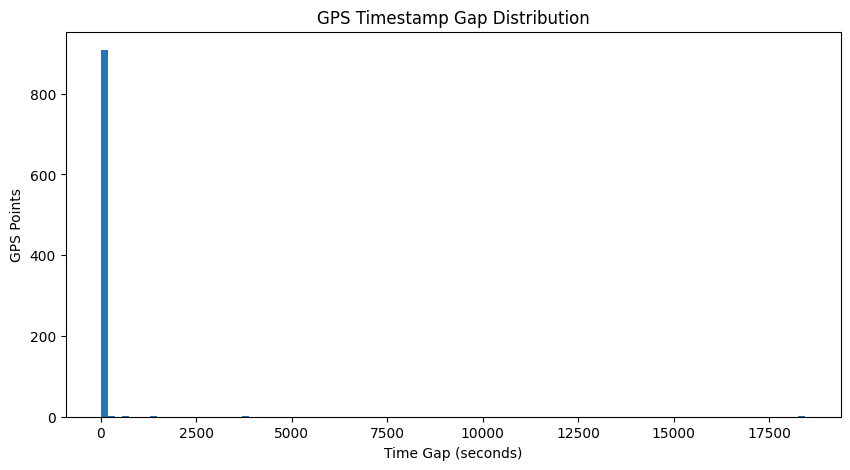

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["time_gap_seconds"].dropna(),
    bins=100
)
plt.xlabel("Time Gap (seconds)")
plt.ylabel("GPS Points")
plt.title("GPS Timestamp Gap Distribution")
plt.show()

# Large Gps Gaps

In [13]:
large_gaps = df[
    df["time_gap_seconds"] > 300]
print(
    "Gaps > 5 minutes:",
    len(large_gaps))

Gaps > 5 minutes: 6


In [14]:
print(
    f"{len(large_gaps) / len(df) * 100:.2f}%"
)

0.66%


# Speed Analysis

In [15]:
print(
    f"{len(large_gaps) / len(df) * 100:.2f}%")

0.66%


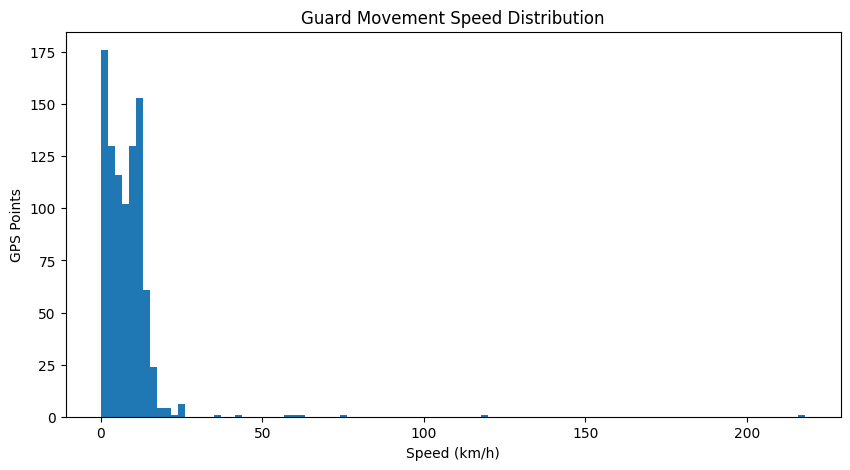

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["speed_kmh"].dropna(),
    bins=100
)
plt.xlabel("Speed (km/h)")
plt.ylabel("GPS Points")
plt.title("Guard Movement Speed Distribution")

plt.show()

In [17]:
print(
    df["speed_kmh"]
    .quantile([0.50, 0.90, 0.95, 0.99, 0.999]))

0.500      7.307210
0.900     13.385820
0.950     15.451234
0.990     25.263056
0.999    126.999990
Name: speed_kmh, dtype: float64


# GPS jump Investigation

In [18]:
gps_jumps = df[
    df["gps_jump"] == True
]
print(
    "GPS jump candidates:",
    len(gps_jumps))

GPS jump candidates: 1


In [19]:
print(
    gps_jumps[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "time_gap_seconds",
            "distance_from_previous_m",
            "speed_kmh"
        ]
    ].head(20))

    guard_id           timestamp   latitude   longitude  time_gap_seconds  \
150      000 2008-10-23 04:08:42  39.984397  116.299292              30.0   

     distance_from_previous_m   speed_kmh  
150               1817.893113  218.147174  


# Road Deviation Analysis 

In [20]:
print(
    df["distance_to_road_m"].describe()
)

count    916.000000
mean      13.579800
std       16.865519
min        0.007636
25%        3.327606
50%        7.186341
75%       15.369943
max       73.486863
Name: distance_to_road_m, dtype: float64


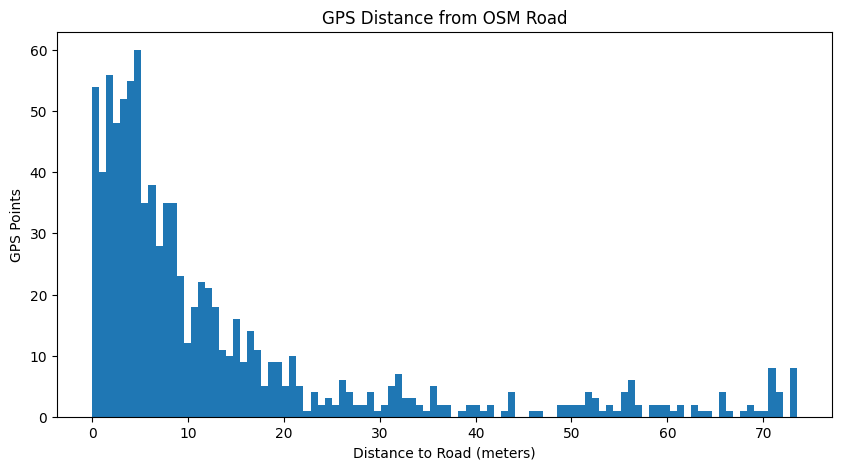

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["distance_to_road_m"].dropna(),
    bins=100)
plt.xlabel("Distance to Road (meters)")
plt.ylabel("GPS Points")
plt.title("GPS Distance from OSM Road")
plt.show()

## Road Match Quality 

In [22]:
print(
    df["road_match_status"]
    .value_counts(dropna=False))

road_match_status
GOOD          568
ACCEPTABLE    227
VERY_FAR       70
FAR            51
Name: count, dtype: int64


In [23]:
road_quality = (
    df["road_match_status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)
print(road_quality)

road_match_status
GOOD          62.01
ACCEPTABLE    24.78
VERY_FAR       7.64
FAR            5.57
Name: proportion, dtype: float64


# Trajectory-wise Behavioral EDA

In [24]:
print("Total GPS records:", len(df))
print("Total guards:", df["guard_id"].nunique())
print("\nGPS records per guard:")
print(
    df["guard_id"]
    .value_counts()
    .describe()
)

Total GPS records: 916
Total guards: 1

GPS records per guard:
count      1.0
mean     916.0
std        NaN
min      916.0
25%      916.0
50%      916.0
75%      916.0
max      916.0
Name: count, dtype: float64


In [25]:
guard_counts = (
    df.groupby("guard_id")
    .size()
    .sort_values(ascending=False)
)
print(guard_counts.head(20))

guard_id
000    916
dtype: int64


# Guard-wise Movement Distance

In [26]:
guard_distance = (
    df.groupby("guard_id")["distance_from_previous_m"]
    .sum()
    .sort_values(ascending=False)
)
print(guard_distance.head(20))

guard_id
000    15015.728516
Name: distance_from_previous_m, dtype: float64


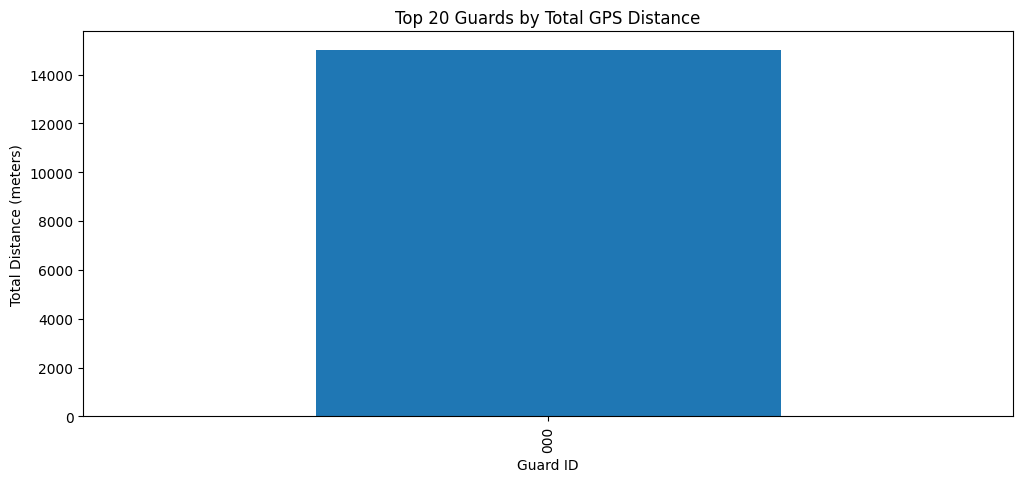

In [27]:
plt.figure(figsize=(12, 5))
guard_distance.head(20).plot(kind="bar")
plt.xlabel("Guard ID")
plt.ylabel("Total Distance (meters)")
plt.title("Top 20 Guards by Total GPS Distance")
plt.xticks(rotation=90)
plt.show()

# Average Speed per guard

In [28]:
guard_speed = (
    df.groupby("guard_id")["speed_kmh"]
    .agg(
        mean_speed="mean",
        median_speed="median",
        max_speed="max"
    )
)
print(guard_speed.head(20))

          mean_speed  median_speed   max_speed
guard_id                                      
000         8.049921       7.30721  218.147174


In [29]:
guard_speed["mean_speed"].describe()

count    1.000000
mean     8.049921
std           NaN
min      8.049921
25%      8.049921
50%      8.049921
75%      8.049921
max      8.049921
Name: mean_speed, dtype: float64

# Guard-wise GPS data duration

In [32]:
guard_duration = (
    df.groupby("guard_id")["timestamp"]
    .agg(
        start_time="min",
        end_time="max"
    ))
guard_duration["duration_hours"] = (
    guard_duration["end_time"]
    - guard_duration["start_time"]
).dt.total_seconds() / 3600

print(
    guard_duration.head(20))

                  start_time            end_time  duration_hours
guard_id                                                        
000      2008-10-23 02:53:04 2008-10-23 11:11:12        8.302222


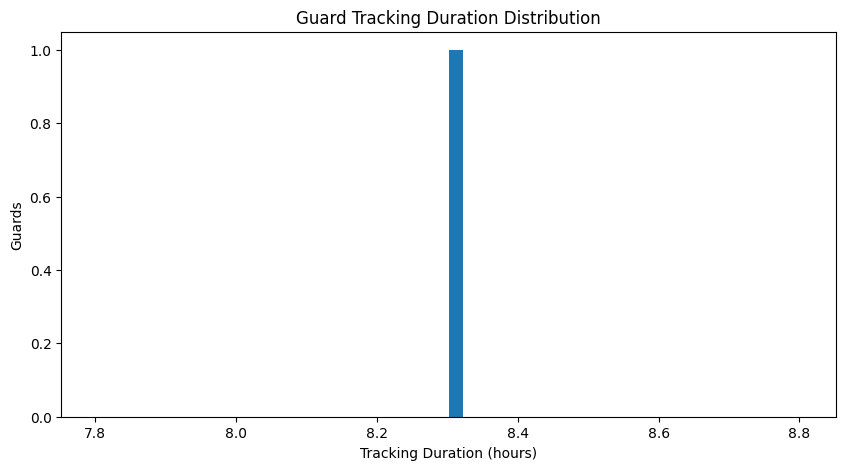

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(
    guard_duration["duration_hours"].dropna(),
    bins=50)
plt.xlabel("Tracking Duration (hours)")
plt.ylabel("Guards")
plt.title("Guard Tracking Duration Distribution")
plt.show()

# Active Hour Analysis

In [35]:
df["hour"] = df["timestamp"].dt.hour
hourly_activity = (
    df.groupby("hour")
    .size())

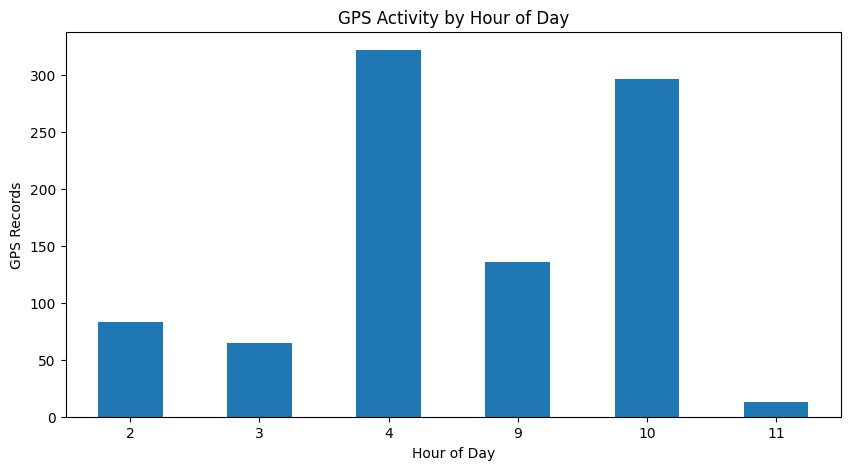

In [36]:
plt.figure(figsize=(10, 5))
hourly_activity.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("GPS Records")
plt.title("GPS Activity by Hour of Day")
plt.xticks(rotation=0)
plt.show()

# Movement vs stationary behavior

In [37]:
df["is_stationary"] = (
    df["distance_from_previous_m"] < 2)

In [38]:
stationary_percentage = (
    df["is_stationary"].mean()* 100)

print(f"Stationary GPS points: {stationary_percentage:.2f}%")

Stationary GPS points: 13.32%


# Stationary Periods

In [39]:
stationary_counts = (
    df.groupby("guard_id")["is_stationary"]
    .sum()
    .sort_values(ascending=False))
print(stationary_counts.head(20))

guard_id
000    122
Name: is_stationary, dtype: int64


# Road deviation per guard

OSM feature use.

In [42]:
guard_road_deviation = (
    df.groupby("guard_id")["distance_to_road_m"]
    .agg(
        mean_distance="mean",
        median_distance="median",
        max_distance="max" ))
print(
    guard_road_deviation.head(1)
)

          mean_distance  median_distance  max_distance
guard_id                                              
000             13.5798         7.186341     73.486863


# Road deviation distribution

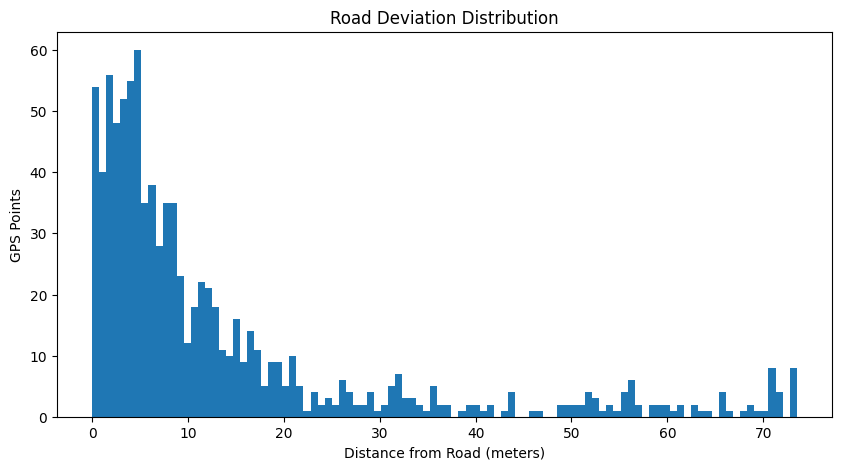

In [43]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["distance_to_road_m"].dropna(),
    bins=100)
plt.xlabel("Distance from Road (meters)")
plt.ylabel("GPS Points")
plt.title("Road Deviation Distribution")
plt.show()

In [44]:
print(
    df["distance_to_road_m"]
    .quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]))

0.50     7.186341
0.75    15.369943
0.90    36.167262
0.95    56.190148
0.99    71.613201
Name: distance_to_road_m, dtype: float64


# Guard behavioral summary

In [45]:
guard_behavior = (
    df.groupby("guard_id")
    .agg(
        gps_points=("guard_id", "size"),
        total_distance_m=(
            "distance_from_previous_m",
            "sum"),
        avg_speed_kmh=(
            "speed_kmh",
            "mean"),
        median_speed_kmh=(
            "speed_kmh",
            "median"),
        max_speed_kmh=(
            "speed_kmh",
            "max"),
        avg_road_distance_m=(
            "distance_to_road_m",
            "mean"),
        max_road_distance_m=(
            "distance_to_road_m",
            "max"),
        gps_jumps=(
            "gps_jump",
            "sum" )))

In [46]:
print(guard_behavior.head(20))

          gps_points  total_distance_m  avg_speed_kmh  median_speed_kmh  \
guard_id                                                                  
000              916      15015.728516       8.049921           7.30721   

          max_speed_kmh  avg_road_distance_m  max_road_distance_m  gps_jumps  
guard_id                                                                      
000          218.147174              13.5798            73.486863          1  


# Behavioral EDA final overview

In [48]:
print(
    guard_behavior.describe())

       gps_points  total_distance_m  avg_speed_kmh  median_speed_kmh  \
count         1.0          1.000000       1.000000           1.00000   
mean        916.0      15015.728516       8.049921           7.30721   
std           NaN               NaN            NaN               NaN   
min         916.0      15015.728516       8.049921           7.30721   
25%         916.0      15015.728516       8.049921           7.30721   
50%         916.0      15015.728516       8.049921           7.30721   
75%         916.0      15015.728516       8.049921           7.30721   
max         916.0      15015.728516       8.049921           7.30721   

       max_speed_kmh  avg_road_distance_m  max_road_distance_m  gps_jumps  
count       1.000000               1.0000             1.000000        1.0  
mean      218.147174              13.5798            73.486863        1.0  
std              NaN                  NaN                  NaN        NaN  
min       218.147174              13.5798      